## Сжатие изображения без потери узнаваемости изображения 

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import urllib.request

from scipy.stats import stats
from sklearn.decomposition import PCA

import importlib
import utils          
importlib.reload(utils)

from utils import PCA_image_monochrome_compression, PCA_image_color_compression

Загрузим картинку и нарисуем ее в монохромный формат

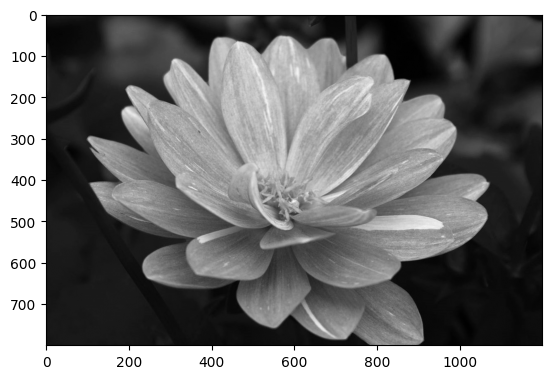

In [97]:
url = "https://www.dropbox.com/s/xoos0myk285efyu/flower.png?dl=1"
urllib.request.urlretrieve(url, "flower.png")   # сохраняем как flower.png

img = cv2.cvtColor(cv2.imread('flower.png'), cv2.COLOR_BGR2GRAY) # преобразует цветное изображение (BGR) в оттенки серого
plt.imshow(img, cmap = 'gray')
plt.show()

In [31]:
img.shape

(800, 1200)

In [118]:
print(f'На картинке {img.shape[0] * img.shape[1]} пикселей ({img.shape[0]} на {img.shape[1]})')

На картинке 2073600 пикселей (1080 на 1920)


Масштабируем данные, поделив значения в матрице на 255

In [35]:
img_scaled = img / 255.0

Обучим PCA с 50-ю компонентами. Снизим размерность.

In [79]:
pca = PCA(n_components=50)
img_PCA_50 = pca.fit_transform(img_scaled)

prop_var = pca.explained_variance_ratio_
eigenvalues = pca.explained_variance_

PC_numbers = np.arange(pca.n_components_) + 1

print(f'Доля дисперсии, объясняемая первыми 50-ю главными компонентами: {sum(prop_var)}')

Доля дисперсии, объясняемая первыми 50-ю главными компонентами: 0.9854897469350233


Нарисуем график, на котором отобразим долю дисперсии, объясняемой каждой из первых 50-ти компонент

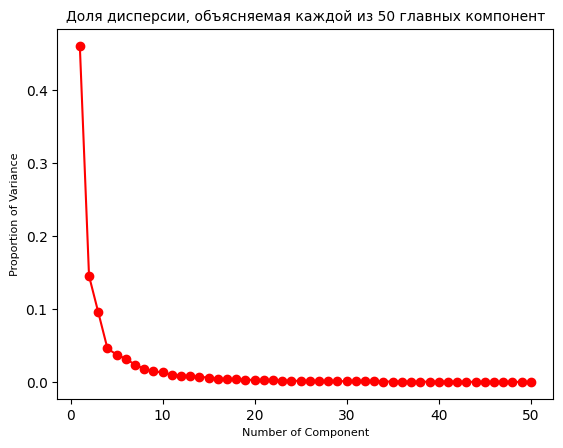

In [59]:
plt.plot(PC_numbers,
         prop_var,
         'ro-')
plt.title(f'Доля дисперсии, объясняемая каждой из {len(PC_numbers)} главных компонент', fontsize = 10)
plt.ylabel('Proportion of Variance', fontsize = 8)
plt.xlabel('Number of Component', fontsize = 8)
plt.show()

Восстановим изображение, используя pca.inverse_transform

In [54]:
img_reconstructed = pca.inverse_transform(img_PCA_50)

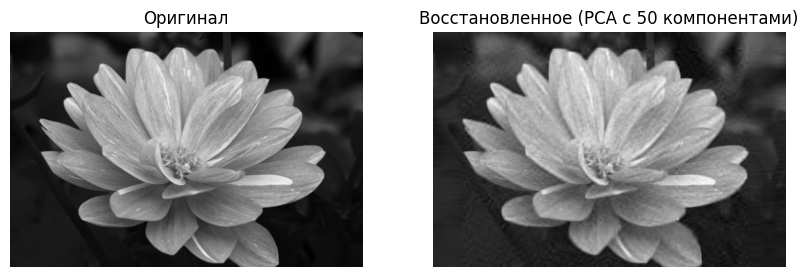

In [56]:
# Отображение
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Оригинал')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_reconstructed, cmap='gray')
plt.title('Восстановленное (PCA c 50 компонентами)')
plt.axis('off')
plt.show()

Подберем минимальное количество компонент, при которых сжатое изображение визуально практически не отличается от исходного. 

Подбор происходит перебором, ориентируемся на визуальный результат

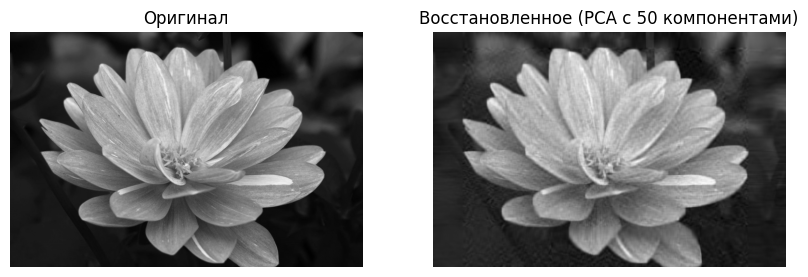

In [105]:
img_mono = PCA_image_monochrome_compression(img_original=img, num_of_components=50)

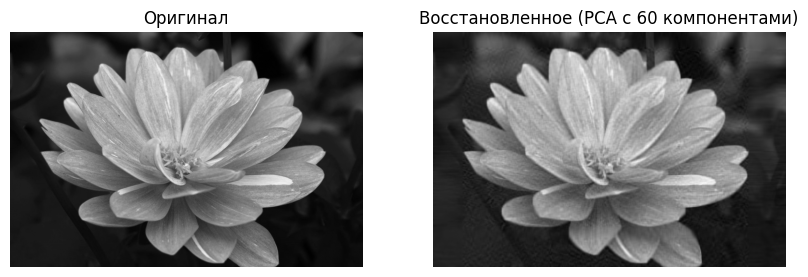

In [108]:
img_mono = PCA_image_monochrome_compression(img_original=img, num_of_components=60)

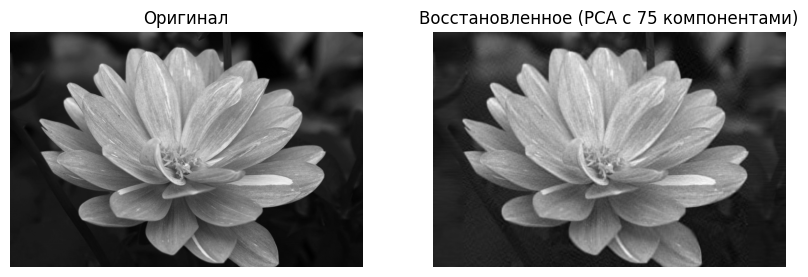

In [109]:
img_mono = PCA_image_monochrome_compression(img_original=img, num_of_components=75)

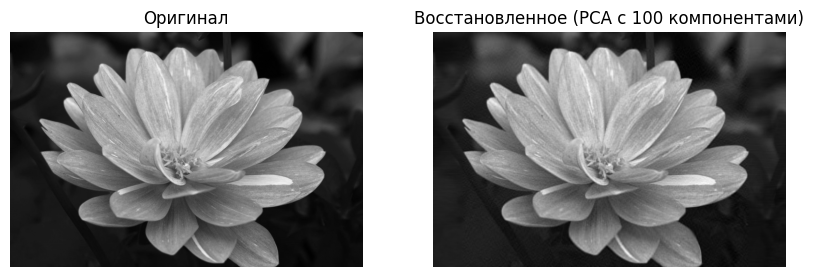

In [110]:
img_mono = PCA_image_monochrome_compression(img_original=img, num_of_components=100)

Попробуем проделать все действия ноутбука, но уже с цветным изображением.

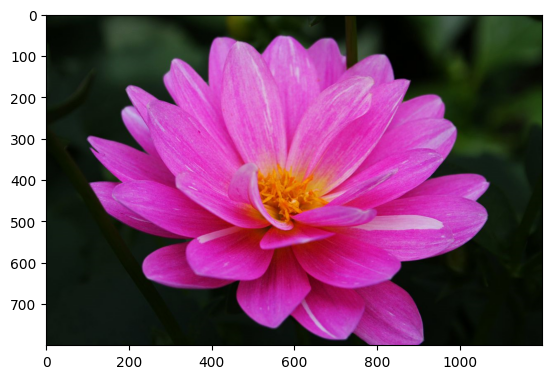

In [98]:
img_color = cv2.cvtColor(cv2.imread('flower.png'), cv2.COLOR_BGR2RGB)
plt.imshow(img_color)
plt.show()

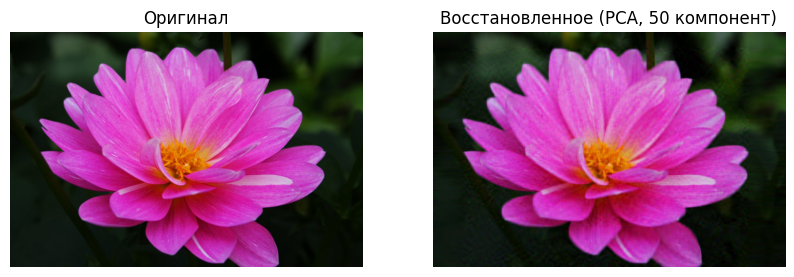

In [113]:
img_compr = PCA_image_color_compression(img_color, 50)

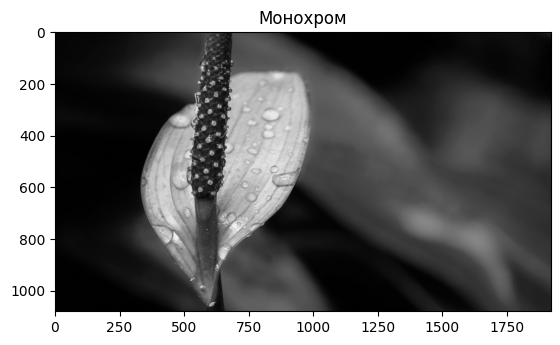

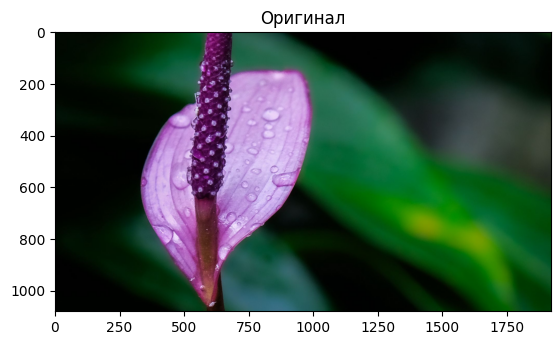

In [114]:
url = "https://images.wallpaperscraft.ru/image/single/anturium_tsvetok_kapli_1102157_1920x1080.jpg"
urllib.request.urlretrieve(url, "anthurium.jpg")

img = cv2.cvtColor(cv2.imread('anthurium.jpg'), cv2.COLOR_BGR2GRAY)
plt.title('Монохром')
plt.imshow(img, cmap = 'gray')
plt.show()

img_color = cv2.cvtColor(cv2.imread('anthurium.jpg'), cv2.COLOR_BGR2RGB)
plt.title('Оригинал')
plt.imshow(img_color)
plt.show()

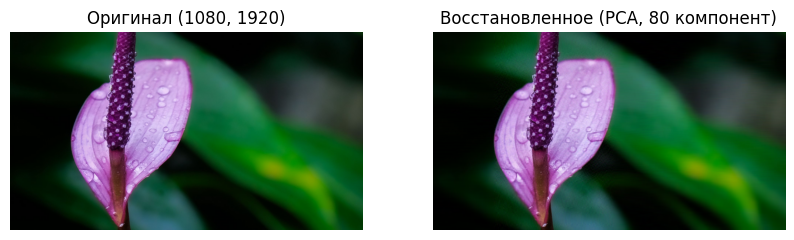

In [129]:
img_compr = PCA_image_color_compression(img_color, 80)

In [127]:
img_color[:, :, 0].shape

(1080, 1920)